## Higgs Effective Field Theory (HEFT) Study: Training
> Created: Feb 12, 2024 Nicola de Filippis, Kurtis Johnson, Harrison B. Prosper, Ryne Starnes<br>
> Updated: Mar 22, 2026 HBP: Modernize.

### Introduction

In this notebook, we model the HEFT di-Higgs cross section[1] (per 15 GeV in the di-Higgs mass, $m_{hh}$) in which the 15 GeV bin size is mapped to a dimensionless value of 0.01. The HEFT parameter space is defined by the 5 parameters $\theta = c_{hhh}, c_{t}, c_{tt}, c_{ggh}, c_{gghh}$. 

\begin{align}
    \sigma(m_{gg}, \theta) & = \boldsymbol{c}(\theta) \cdot \boldsymbol{a}(m_{hh}), 
\end{align}

for the cross section per bin, $\sigma$, where

\begin{align*}
    \boldsymbol{c}(\theta) & = (\\
             c_{t}^4,\\
             c_{tt}^2,\\
             c_{t}^2 c_{hhh}^2,\\
             c_{ggh}^2 c_{hhh}^2,\\
             c_{gghh}^2,\\
             c_{tt} c_{t}^2,\\             
             c_{hhh} c_{t}^3,\\
             c_{t} c_{hhh} c_{tt},\\
             c_{ggh} c_{hhh} c_{tt},\\
             c_{tt} c_{gghh},\\
             c_{ggh} c_{hhh} c_{t}^2,\\
             c_{gghh} c_{t}^2, \\
             c_{hhh}^2 c_{ggh} c_{t},\\
             c_{gghh} c_{t} c_{hhh},\\
             c_{ggh} c_{gghh} c_{hhh},\\
             c_{t}^3 c_{ggh},\\
             c_{t} c_{tt} c_{ggh},\\
             c_{t} c_{ggh}^2 c_{hhh},\\
             c_{t} c_{ggh} c_{gghh}, 
             c_{t}^2 c_{ggh}^2,\\
             c_{tt} c_{ggh}^2,\\
             c_{ggh}^3 c_{hhh},\\
             c_{ggh}^2 c_{gghh}\\
             )
\end{align*}
is a vector of polynomials in the HEFT parameters
and $\boldsymbol{a}(m_{hh})$ is a vector of coefficients to be determined. The cross section per bin is given by the dot product of these vectors.

### Model

We attempt to model the 23 functions $a_i(m_{hh})$ using a *single* deep neural network with one input, $m_{hh}$, and 23 outputs, one for each function and a 1-parameter neural network. The training data for this notebook are prepared in the notebook `heft_prepare_traindata.ipynb`.

### References
  1. Lina Alasfar *et al.*, arXiv:2304.01968v1

In [3]:
import os, sys

# the standard module for tabular data
import pandas as pd

# the standard module for array manipulation
import numpy as np

# the standard modules for high-quality plots
import matplotlib as mp
import matplotlib.pyplot as plt

# pytorch
import torch
import torch.nn as nn
import torch.utils.data as td

# module to reimport Python modules
import importlib

# module for shell utilities
import shutil

# di-Higgs ML module
import dihiggs.nn as mlp
import dihiggs.utils.data as dat
import dihiggs.utils.monitor as mon

from tqdm import tqdm

# update fonts
plt.rcParams.update({
  "text.usetex": shutil.which('latex') is not None,
  "font.family": "sans-serif",
  "font.size": 12
})

## Computational device

In [4]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'\n\tAvailable device: {str(DEVICE):4s}\n')


	Available device: cpu 



## Load training data

In [5]:
datafile = f'../data/heft_wide_gauss_traindata_13TeV.csv'

if dat.download(datafile):
    print(f'loading {datafile}')
    df = pd.read_csv(datafile)
    
    sample_size = len(df)
    print(f'sample size: {sample_size}')
    
    print(f'''
        min(sigma):  {df.sigma.min():10.3e} pb
        max(sigma):  {df.sigma.max():10.3e} pb
        avg(sigma):  {df.sigma.mean():10.3e} pb
        ''')
else:
    raise RuntimeError(f'''
    Download of {datafile} failed!
    ''')
    
df[:5]

loading ../data/heft_wide_gauss_traindata_13TeV.csv
sample size: 357958

        min(sigma):   6.394e-07 pb
        max(sigma):   3.140e+01 pb
        avg(sigma):   1.093e-01 pb
        


,ID,klambda,CT,CTT,CGGH,CGGHH,mhh,sigma
0,3884,-0.612707,3.920933,1.833762,0.359315,1.801779,0.275,0.058550
1,3174,-10.748095,-2.201843,-0.598258,-0.828984,1.408203,0.625,0.003439
2,4285,2.797025,3.431533,-3.807565,-1.308453,-2.804408,0.155,1.017687
3,2537,5.935780,-0.266438,-2.554013,-0.599508,-0.543163,0.705,0.001098
4,1354,3.262933,0.434158,-0.624957,0.322330,-0.212242,0.105,0.004234


## Load model

In [7]:
import heftnet as NN
importlib.reload(NN)

print(f'''
    Model name: {NN.NAME}
    Features:   {NN.FEATURES}
    Target:     {NN.TARGET}
''')


    Model name: heftnet
    Features:   ['mhh', 'klambda', 'CT', 'CTT', 'CGGH', 'CGGHH']
    Target:     sigma



## Configuration

In [8]:
batch_size = 2048
train_size = 300_000
train_size = int(batch_size * np.ceil(train_size / batch_size))
test_size  =  50_000
val_size   = sample_size - train_size - test_size

train_size, val_size, test_size

(301056, 6902, 50000)

In [10]:
# Name of model
name = 'dihiggs'

# Choose whether to create or load a configuration file
load_existing_config = False

if load_existing_config:
    config = mlp.Config(f'{name}.yaml')
else:
    # Create new configuration
    config = mlp.Config(name, dirname='L1Loss')

    # -------------------------------------------------------------
    # Model architecture (FCNN)
    # -------------------------------------------------------------
    config('model_name', NN.NAME)
    config('features', NN.FEATURES)
    config('target', NN.TARGET)
    config('activation', NN.ACTIVATION)
    
    # -------------------------------------------------------------
    # Training configuration
    # -------------------------------------------------------------
    config('batch_size', batch_size) 
    config('train_size', train_size) # training sample size
    config('test_size',  test_size)  # test sample size
    config('val_size',   val_size)   # validation sample size
 
    config('monitor_step', 100)   # monitor training every n (=10) iterations
    config('frac', 0.015)         # save model if average loss decreases by more
                                  # than frac percent
    # -------------------------------------------------------------
    # Optimizer / scheduler configuration
    # -------------------------------------------------------------
    # A step comprises a given number of iterations, i.e.,
    # the number of steps with a fixed learning rate
    n_steps = 4

    # number of iterations
    n_iterations = 200_000

    # number of iterations per step
    config('n_steps', n_steps)    # number of training steps

    config('n_iterations', n_iterations)

    n_iters_per_step = int(n_iterations / n_steps)
    config('n_iters_per_step', n_iters_per_step)

    config('base_lr', 2.e-3)      # initial learning rate
    config('gamma', 0.5)          # learning rate scale factor
    
    print(f'\nSaving configuration to file {config.cfg_filename}\n')
    config.save()

print(config)


Saving configuration to file runs/L1Loss/dihiggs_config.yaml

name: dihiggs
file:
  losses: runs/L1Loss/dihiggs_losses.csv
  params: runs/L1Loss/dihiggs_params.pth
  init_params: runs/L1Loss/dihiggs_init_params.pth
  plots: runs/L1Loss/dihiggs_plots.png
model_name: heftnet
features:
- mhh
- klambda
- CT
- CTT
- CGGH
- CGGHH
target: sigma
activation: nn.ReLU
batch_size: 2048
train_size: 301056
test_size: 50000
val_size: 6902
monitor_step: 100
frac: 0.015
n_steps: 4
n_iterations: 200000
n_iters_per_step: 50000
base_lr: 0.002
gamma: 0.5



### Train, validation, and test sets
There is some confusion in terminology regarding validation and test samples (or sets). We shall adhere to the defintions given here https://machinelearningmastery.com/difference-test-validation-datasets/):
   
  * __Training Dataset__: The sample of data used to fit the model.
  * __Validation Dataset__: The sample of data used to decide 1) whether the fit is reasonable (e.g., the model has not been overfitted), 2) decide which of several models is the best and 3) tune model hyperparameters.
  * __Test Dataset__: The sample of data used to provide an unbiased evaluation of a final model fit on the training dataset.

The validation set will be some small fraction of the training set and can be used, for example, to decide when to stop the training.

## Prepare Datasets and DataLoaders

### Datasets

In [11]:
X = df[NN.FEATURES].to_numpy(dtype=np.float32)
Y = df[NN.TARGET].to_numpy(dtype=np.float32)

print(f'''
    Features: {NN.FEATURES}
    Targets:  {NN.TARGET}

    X.shape:  {X.shape}
    Y.shape:  {Y.shape}
''')


    Features: ['mhh', 'klambda', 'CT', 'CTT', 'CGGH', 'CGGHH']
    Targets:  sigma

    X.shape:  (357958, 6)
    Y.shape:  (357958,)



In [12]:
importlib.reload(dat)

train_size = config('train_size')
val_size   = config('val_size')
test_size  = config('test_size')

# training dataset (this defines the empirical risk to be minimized)
print('training data')
train_data = dat.Dataset(X, targets=Y,
                         start=0,
                         end=train_size)

# a random subset of the training data to check for overtraining
# by comparing with the empirical risk from the validation set
print('training data for validation')
train_data_val = dat.Dataset(X, targets=Y,
                             start=0,
                             end=train_size,
                             random_sample_size=val_size)

# validation dataset (for monitoring training)
print('validation data')
val_data = dat.Dataset(X, targets=Y,
                       start=train_size,
                       end=train_size + val_size)

# test dataset
print('test data')
test_data= dat.Dataset(X, targets=Y,
                       start=train_size + val_size,
                       end=train_size + val_size + test_size)

training data
Dataset
  shape of x: torch.Size([301056, 6])
  shape of y: torch.Size([301056])

training data for validation
Dataset
  shape of x: torch.Size([6902, 6])
  shape of y: torch.Size([6902])

validation data
Dataset
  shape of x: torch.Size([6902, 6])
  shape of y: torch.Size([6902])

test data
Dataset
  shape of x: torch.Size([50000, 6])
  shape of y: torch.Size([50000])



### DataLoaders

In [13]:
print('train data loader')
train_loader = dat.DataLoader(train_data,
                              batch_size=config('batch_size'),
                              num_iterations=config('n_iterations'))

print('train data loader for validation')
train_loader_val = dat.DataLoader(train_data_val,
                                  batch_size=len(train_data_val))

print('validation data loader')
val_loader  = dat.DataLoader(val_data,
                             batch_size=len(val_data))

print('test data loader')
test_loader = dat.DataLoader(test_data,
                             batch_size=len(test_data))

train data loader
DataLoader
  Number of iterations has been specified
  maxiter:          200000
  batch_size:         2048
  shuffle_step:        147

train data loader for validation
DataLoader
  maxiter:               1
  batch_size:         6902
  shuffle_step:          1

validation data loader
DataLoader
  maxiter:               1
  batch_size:         6902
  shuffle_step:          1

test data loader
DataLoader
  maxiter:               1
  batch_size:        50000
  shuffle_step:          1



### Empirical risk (that is, average loss)

The empirical risk, which is the **objective function** we shall minimize, is defined by

\begin{align}
R_M(\omega) & = \frac{1}{M} \sum_{m=1}^{M} L(t_m, f_m),
\end{align}

where 

\begin{align*}
    f_m & \equiv f\boldsymbol{x}_m; \omega)
\end{align*}
is the machine learning model whose parameters $\omega$ are to be fitted by minimizing $R_M$. 
The quantity $x = m_{hh}, k_{lambda}, c_{t}, c_{tt}, c_{ggh}, c_{gghh}$ are the inputs to the model and the target $t$ is the predicted cross section (per 15 GeV in $m_{hh}$).

(Aside: The empirical risk $R_M$ approximates the **risk functional**
\begin{align}
R[f] & = \int \cdots \int \, p(t, \boldsymbol{x}) \, L(t, f(\boldsymbol{x}; \omega)) \, dt \, d\boldsymbol{x} ,
\end{align}
where the quantity $p(t, \boldsymbol{x}) \, dt\, d\boldsymbol{x}$ is the probability distribution of the training data from which the sample $\{ (t_m, \boldsymbol{x}_m), m = 1,\cdots, M \}$ is presumed to have been drawn.) 

We fit the model $f$ by minimizing the **absolute loss** (i.e., L1 loss)

\begin{align}
    L(t, f) &= |t - f| ,
\end{align}
where $f$ is given by the dot product
\begin{align}
    f \equiv \sigma(m_{hh}, \theta) & = \boldsymbol{c}(\theta) \cdot \boldsymbol{a}(m_{hh}) .
\end{align}
The 23 functions $a_i(m_{hh})$ are approximated with a *single* neural network with $m_{hh}$ as input and the values of the functions $a_i(m_{hh})$ as outputs. The calculus of variations shows that the minimum of the L1 loss occurs when
\begin{align}
    f(\boldsymbol{x}, \omega^*) & = \text{median}_t [ p(t | \boldsymbol{x}) ],
\end{align}
where $\omega^*$ denotes the best-fit value of $\omega$, $p(t | \boldsymbol{x}) = p(t,  \boldsymbol{x}) / p(\boldsymbol{x})$, and $p(t, \boldsymbol{x})$ is the (typically, *unknown*) probability distribution of the training data.

### Define model for cross section
`heftnet` models the mapping $f : m_{hh}, k_{lambda}, c_{t}, c_{tt}, c_{ggh}, c_{gghh} \rightarrow \sigma$ using the known functional dependence of the cross section on $m_{hh}$, the Wilson coefficients, $\theta = k_{lambda}, c_{t}, c_{tt}, c_{ggh}, c_{gghh}$, and the observable-dependent functions $\boldsymbol{a}$. The mapping $g : m_{hh} \rightarrow \boldsymbol{a}$ is modeled with a function of the form
\begin{align}
    a_j(m_{hh}) & = P_j(m_{hh}) e^{Q_j(m_{hh})},
\end{align}
where $P$ and $Q$ are neural networks with one input and 23 outputs.

## Train!

In [14]:
def train(objective, optimizer, scheduler, monitor,
          train_loader, train_small_loader, val_loader):

    monitor.start()
    
    for x, y in train_loader:

        # set mode to training so that training-specific
        # operations such as dropout, etc., are enabled.
        objective.train()

        # clear all gradients
        optimizer.zero_grad()

        # compute empirical risk
        R = objective(x, y)

        # compute gradients
        R.backward()

        # take one step downhill in the empirical risk landscape
        optimizer.step()

        # check whether to update learning rate
        scheduler.step()

        # I'm alive printout
        if monitor.step():

            # compute average losses on training and validation data
            t_loss = mlp.compute_avg_loss(objective, train_small_loader)
            v_loss = mlp.compute_avg_loss(objective, val_loader)

            # return current learning rate
            lr = scheduler.lr()

            # update loss file
            monitor(t_loss, v_loss, lr)
            
    monitor.reset()

In [15]:
importlib.reload(NN)

model     = NN.HEFTNet().to(DEVICE)

objective = mlp.Objective(model, nn.L1Loss()).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=config('base_lr'))

# Instantiate learning rate step scheduler
scheduler = mlp.LRStepScheduler(
    optimizer,  
    n_steps=config('n_steps'), 
    n_iters_per_step=config('n_iters_per_step'), 
    base_lr=config('base_lr'), 
    gamma=config('gamma'))

# Instantiate object that saves average losses to
# a csv file for realtime monitoring as well as
# the model with the lowest average loss.
monitor = mon.Monitor(
    config('n_iterations'),
    config('file/losses'),
    monitorstep=config('monitor_step'),
    newlossfile=True,
    frac=config('frac'),
    model=model,
    paramsfile=config('file/params'))

print(model)
print(f'Number of parameters: {mlp.number_of_parameters(model)}')

number of milestones:          3

Step | Milestone | LR
-----------------------------
   0 |         0 | 2.0e-03   
-----------------------------
   1 |     50000 | 1.0e-03   
   2 |    100000 | 5.0e-04   
   3 |    150000 | 2.5e-04   


HEFTNet(
  (P): Sequential(
    (0): Linear(in_features=1, out_features=25, bias=True)
    (1): ReLU()
    (2): Linear(in_features=25, out_features=25, bias=True)
    (3): ReLU()
    (4): Linear(in_features=25, out_features=25, bias=True)
    (5): ReLU()
    (6): Linear(in_features=25, out_features=25, bias=True)
    (7): ReLU()
    (8): Linear(in_features=25, out_features=25, bias=True)
    (9): ReLU()
    (10): Linear(in_features=25, out_features=25, bias=True)
    (11): ReLU()
    (12): Linear(in_features=25, out_features=23, bias=True)
    (13): Tanh()
  )
  (Q): Linear(in_features=1, out_features=23, bias=True)
)
Number of parameters: 3944


In [13]:
TRAIN = True

if TRAIN:
    train(objective, optimizer, scheduler, monitor,
          train_loader, train_loader_val, val_loader)

monlosses runs/L1Loss/dihiggs_losses.csv

		learning rate:  2.000e-03
     49900| 49.90%|00:04:34|00:04:35| 182.0 it/s|3.618e-03|3.481e-03|     49900|
		learning rate:  1.000e-03
     99900| 99.90%|00:09:05|00:00:00| 183.3 it/s|3.454e-03|3.127e-03|     99900|

### Apply trained model to test data

In [15]:
Load_lowest_loss_model = True

if Load_lowest_loss_model:
    modelfile = config('file/params')
    print('load lowest loss model dictionary: %s' % modelfile)
    model.load(modelfile)

x, t = next(iter(test_loader))
y = model(x).detach().cpu().numpy()
t = t.detach().cpu().numpy()

load lowest loss model dictionary: runs/L1Loss/dihiggs_params.pth


(50000,)

## Plot NN vs. POWHEG cross section

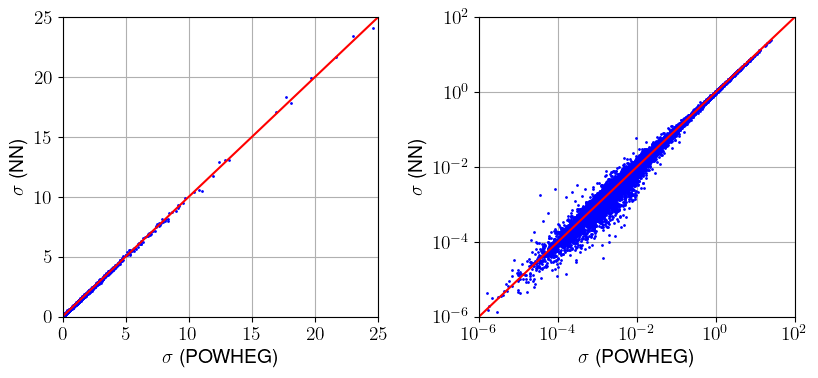

In [19]:
def plot_results(y, t, 
                 xmin=1e-6, xmax=1e2, 
                 ymin=1e-6, ymax=1e2, 
                 ftsize=14, 
                 filename='figures/fig_results.png'):
    
    # create an empty figure
    fig = plt.figure(figsize=(8.4, 4))
 
    # add a subplot to it
    for i in range(2):
        nrows, ncols, index = 1,2,i+1
        ax  = fig.add_subplot(nrows, ncols, index)
                
        if i < 1:
            ax.set_xlim(0, 25)
            ax.set_ylim(0, 25)
        else:
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ax.set_xscale('log')
            ax.set_yscale('log')
                        
        ax.set_xlabel(r'$\sigma$ (POWHEG)', fontsize=ftsize)
        ax.set_ylabel(r'$\sigma$ (NN)', fontsize=ftsize)

        ax.plot(y, t, 'b', marker='.', markersize=2, linestyle='')
        ax.plot([xmin, xmax], [ymin, ymax], linestyle='solid', color='red')
    
        ax.grid(True, which="both", linestyle='-')

    fig.tight_layout()
    os.system('mkdir -p figures')
    plt.savefig(filename)
    plt.close()
    
plot_results(y, t)

### Plot coefficients

23


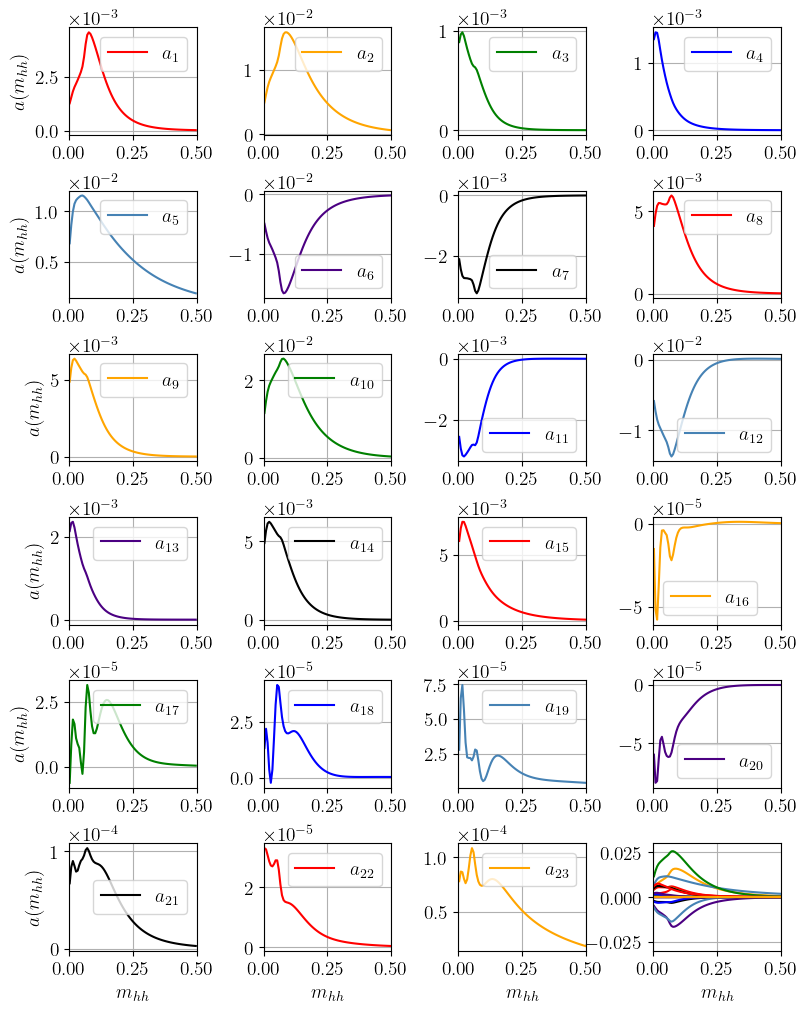

In [20]:
def plot_coeffs(dnn, ftsize=14):
    
    # define equally spaced points for m_hh
    xbins= 80
    xmin = 0
    xmax = 0.5
    x = np.linspace(xmin, xmax, xbins+1)
    x = (x[1:]+x[:-1])/2

    # detach from computation tree and return coefficients as a numpy array
    a = dnn.coeffs( torch.Tensor(x).to(DEVICE) ).detach().cpu().numpy()
    nplots = len(a[0])
    print(nplots)
    
    # create a mosaic of plots
    # a b c
    # d e f
    # : : :
    # o p p
    # last plot occupies two slots
    fig, axes = plt.subplot_mosaic('abcd;'
                                   'efgh;'
                                   'ijkl;'
                                   'mnop;'
                                   'qrst;'
                                   'uvwx', 
                                   figsize=(8, 10))

    # get subplot keys a, b, c, etc.
    keys = list(axes.keys())
    keys.sort()

    kolor = ['red', 'orange', 'green', 'blue', 'steelblue', 'indigo', 'black']

    nrows = 6
    ncols = 4
    
    for i, key in enumerate(keys[:-1]):
        
        ax = axes[key]

        ax.set_xlim(xmin, xmax)
        
        if i > (nrows-1) * ncols-1:
            ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)
            
        if i % ncols == 0:
            ax.set_ylabel(r'$a(m_{hh})$', fontsize=ftsize)
            
        ax.ticklabel_format(axis='y', scilimits=[-2, 2])
        
        # plot (i+1)th coefficient
        y = a.T[i]
        c = kolor[i % len(kolor)]
        index = i + 1
        ax.plot(x, y, color=c, label='$a_{%d}$' % index)
        ax.legend()
        ax.grid()

    # last plot: superimpose all coefficient plots
    ax = axes['x']
    
    ax.set_xlim(xmin, xmax)
    ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)

    ymin = -0.03
    ymax =  0.03
    ax.set_ylim(ymin, ymax)
    
    for i in range(nplots):
        # plot (i+1)th coefficient
        y = a.T[i]
        c = kolor[i % len(kolor)]
        index = i + 1
        ax.plot(x, y, color=c)
    ax.grid()
    
    # need the following to make layout look reasonable
    fig.tight_layout()
    os.system('mkdir -p figures')
    plt.savefig('figures/fig_coefficients.png')
    plt.close()
    
plot_coeffs(model)

## Plot spectra

 1. Compute spectra approximated with the NN model.
 2. Compare with POWHEG spectra that have not been used in the training.

## Load test spectra

In [21]:
spectra = pd.read_csv('../data/heft_wide_gauss_testdata_13TeV.csv', nrows=500)
spectra[:5]

,ID,klambda,CT,CTT,CGGH,CGGHH,17,18,19,20,...,87,88,89,90,91,92,93,94,95,96
0,2573,5.548667,0.001127,-1.498415,1.167773,-0.800664,0.004168,0.001641,0.000328,0.000706,...,0.000738,0.000706,0.000673,0.000443,0.000624,0.000558,0.000443,0.000377,0.000558,0.000574
1,3405,1.362614,0.062098,-0.209365,-0.267593,1.521406,0.011459,0.015339,0.016459,0.016540,...,0.002272,0.001834,0.001932,0.001899,0.001769,0.001493,0.001834,0.001721,0.001867,0.001396
2,3430,3.267829,2.100274,2.011320,-2.948384,3.075786,0.010026,0.019230,0.028845,0.035501,...,0.008629,0.008464,0.007807,0.005835,0.006163,0.007396,0.007150,0.007067,0.005588,0.005259
3,1220,-1.888424,2.017534,0.538233,1.308303,-0.489064,0.130243,0.141480,0.156984,0.145855,...,0.000054,0.000054,0.000270,0.000054,0.000162,0.000108,0.000054,0.000108,0.000108,0.000216
4,4129,6.043734,0.092765,-1.787688,0.778852,-0.274286,0.001606,0.000450,0.000385,0.001831,...,0.000530,0.000289,0.000401,0.000273,0.000241,0.000498,0.000401,0.000337,0.000257,0.000337


In [29]:
def get_spectra(model, df, row):

    params = ['klambda', 'CT', 'CTT', 'CGGH', 'CGGHH']
    bins   = [f'{i}' for i in range(17, 97)]
    
    xbins = len(bins)
    xmin  = 0
    xmax  = xbins/100
    
    # define mhh values
    x = np.linspace(xmin, xmax, xbins+1)
    x = (x[1:]+x[:-1])/2

    # get parameter values    
    klambda, ct, ctt, cggh, cgghh = df[params].iloc[row]

    # create input data
    inputs = []
    for mhh in x:
        inputs.append([mhh, klambda, ct, ctt, cggh, cgghh])
  
    # get POWHEG cross sections
    spectrum = df[bins].iloc[row].to_numpy()
    
    # get NN predicted cross section
    inputs = torch.Tensor(np.array(inputs)).to(DEVICE)
    
    model.eval()   
    y = model(inputs).detach().cpu().numpy()       # approximated spectrum 

    return spectrum.sum(), x, y, spectrum, klambda, ct, ctt, cggh, cgghh

In [49]:
def plot_spectra(data, 
                 ftsize=12, 
                 filename='figures/fig_spectra_comparisons.png'):

    print(filename)
    
    plt.rcParams.update({'font.size': 12})
        
    _, x, y, s, _,_,_,_,_ = data[0]
    xbins = len(x)
    xmin, ymin  = 0, 0
    xmax = xbins/100

    # work out number of columns and number of plots
    ncols = 4
    nrows = len(data) // ncols
    ndata = nrows * ncols
    
    # create an empty figure
    fig = plt.figure(figsize=(12, 1.6*nrows))

    # loop over coefficients

    # Turn off LaTex
    plt.rcParams.update({"text.usetex": False})
    
    for i, (total_xsec, x, y, f, klambda, ct,ctt, cggh, cgghh) \
    in enumerate(data):

        index = i+1
        ax  = fig.add_subplot(nrows, ncols, index)

        # setup x-axis
        ax.set_xlim(xmin, xmax)
        
        if i > (nrows-1) * ncols-1:
            ax.set_xlabel(r'$m_{hh}$', fontsize=ftsize)

        # setup y-axis
        ymax = 1.5 * f.max()
        ax.set_ylim(ymin, ymax)
        ax.ticklabel_format(axis='y', scilimits=[-2, 2])
        
        if i % ncols == 0:
            ax.set_ylabel(r'$\sigma$', fontsize=ftsize)

        # annotate plot
        xpos = xmin + 0.02 * (xmax-xmin)
        ypos = ymin + 0.85 * (ymax-ymin)
        ystep= (ymax-ymin)/5
       
        ypos -= 0.5*ystep
        ax.text(xpos, ypos, '%5.2f,%5.2f,%5.2f,%5.2f,%5.2f' % \
                (klambda, ct, ctt, cggh, cgghh), fontsize=10)
        
        ypos -= ystep
        xpos = xmin + 0.40 * (xmax-xmin)
        ax.text(xpos, ypos, r'$\sigma:$ %5.2f pb' % total_xsec, 
                fontsize=12)
        
        # POWHEG spectra
        ax.hist(x, bins=xbins, range=(xmin, xmax), weights=f, 
                    color='green', alpha=0.2)

        # NN-approximated spectra
        ax.plot(x, y, color='blue', linewidth=2)

    fig.tight_layout()
    os.system('mkdir -p figures')
    plt.savefig(filename)
    plt.close()
# ------------------------------------------------------------------
M = len(spectra)
data = []
for row in range(M):
    data.append( get_spectra(model, spectra, row) )    
# sort in order of increasing cross section
data.sort()

0 20

figures/fig_spectra_comparisons_001.png


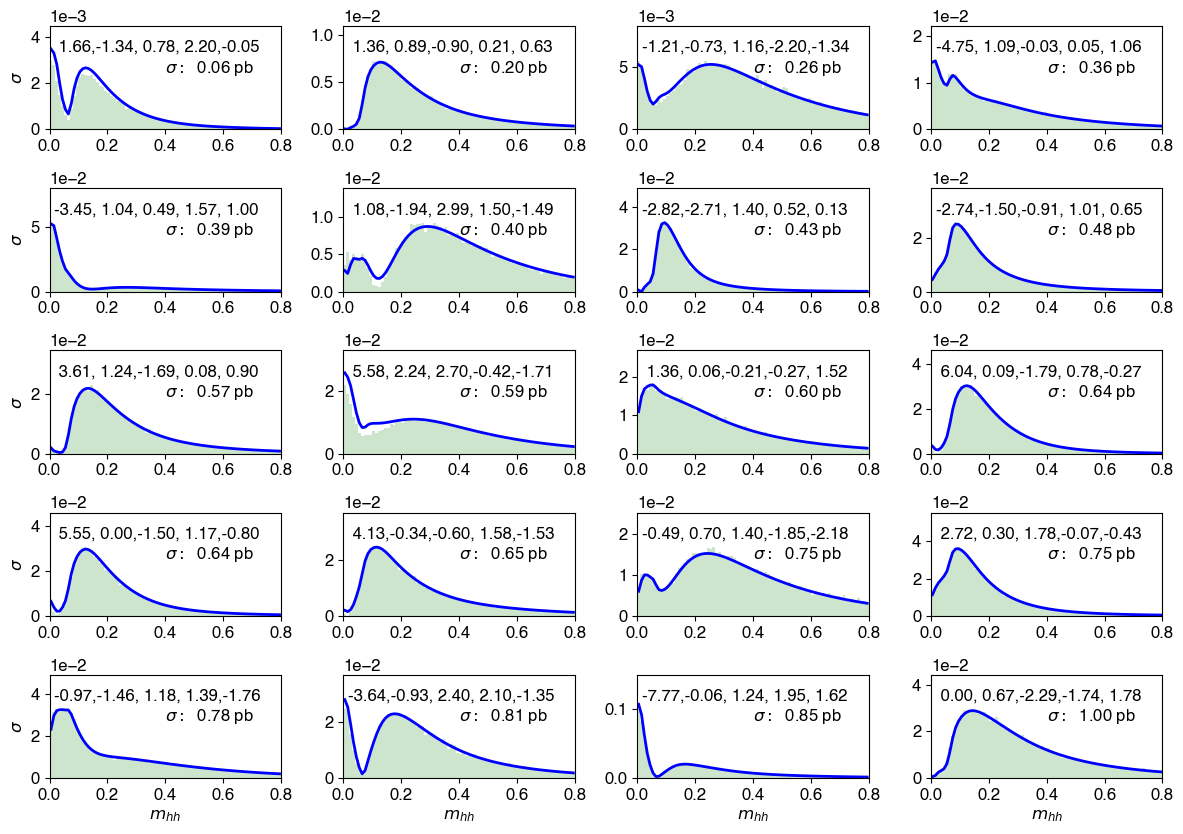

20 40

figures/fig_spectra_comparisons_002.png


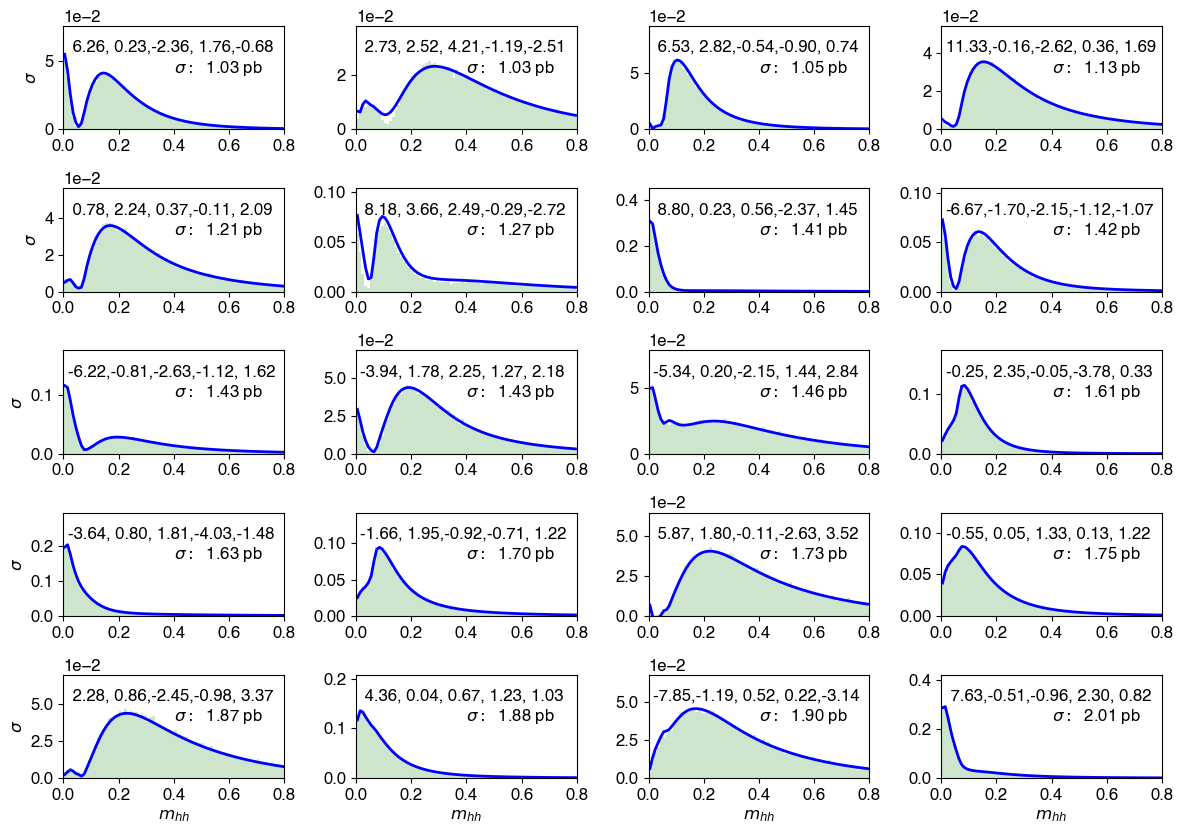

40 60

figures/fig_spectra_comparisons_003.png


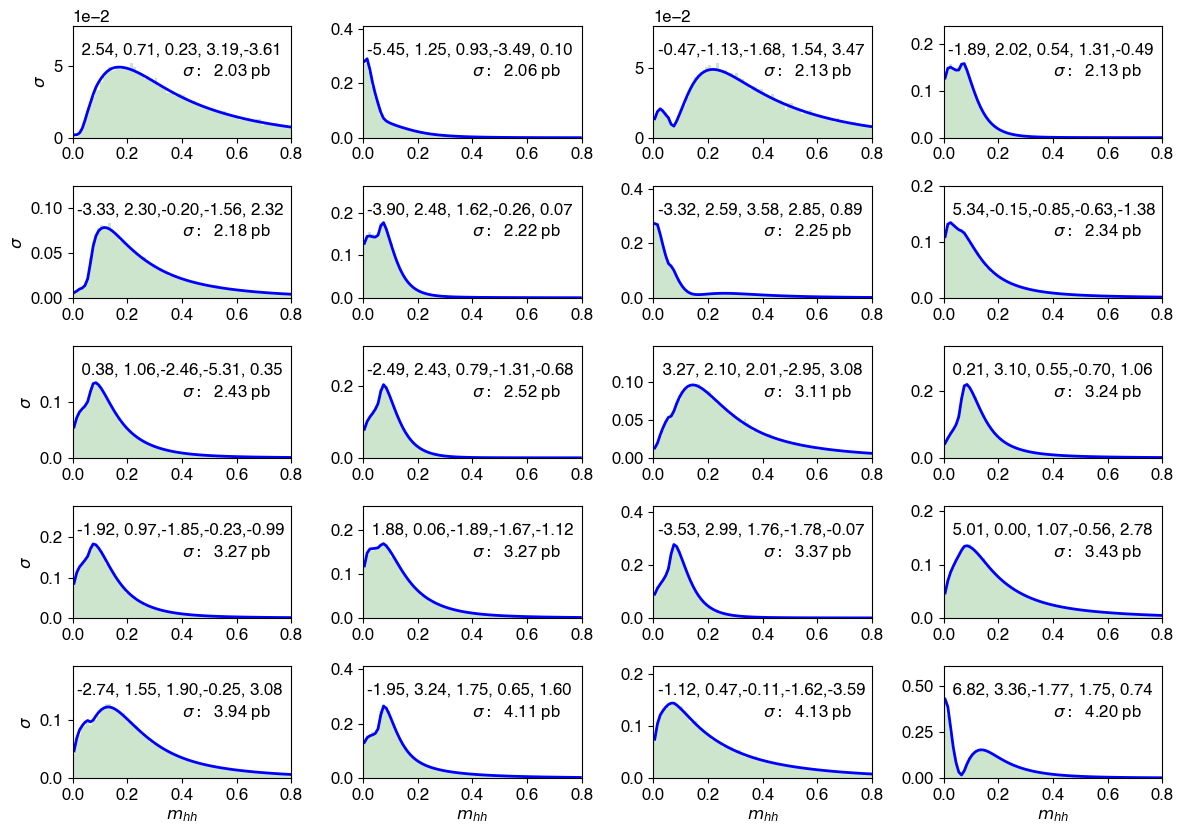

60 80

figures/fig_spectra_comparisons_004.png


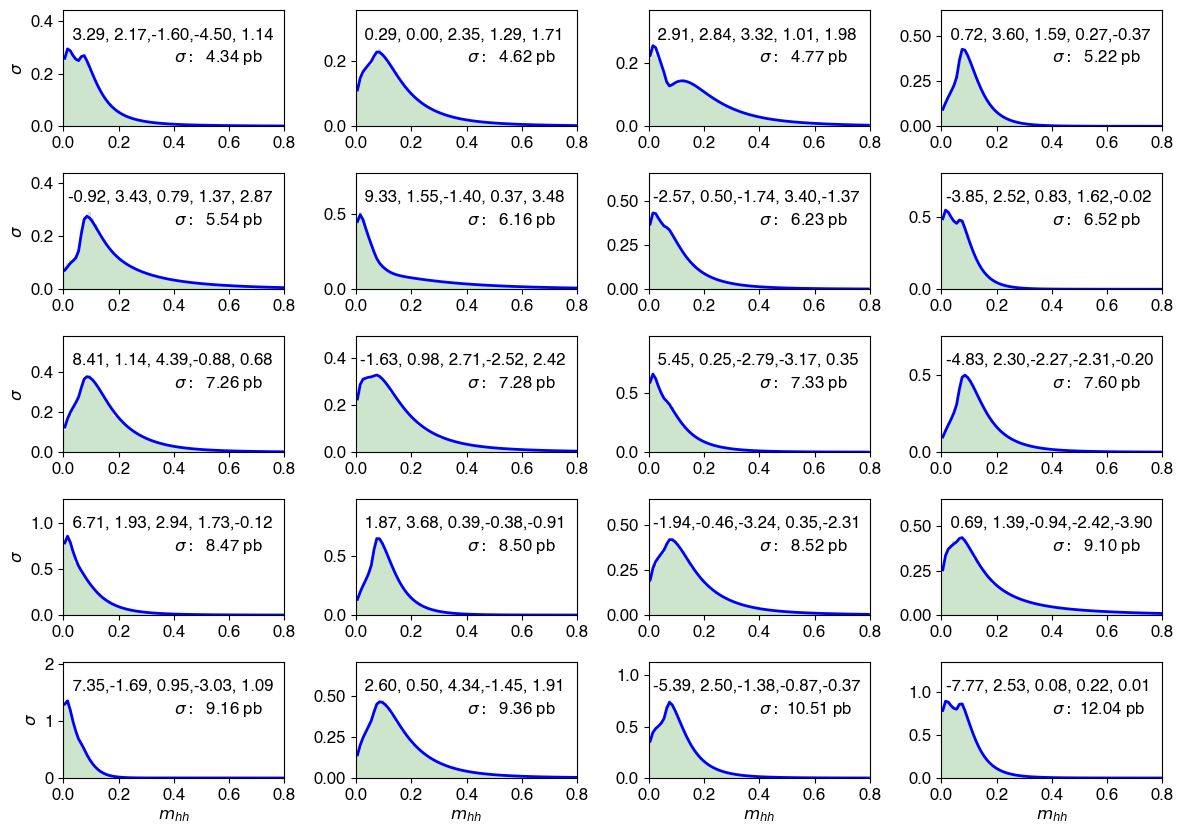

80 100

figures/fig_spectra_comparisons_005.png


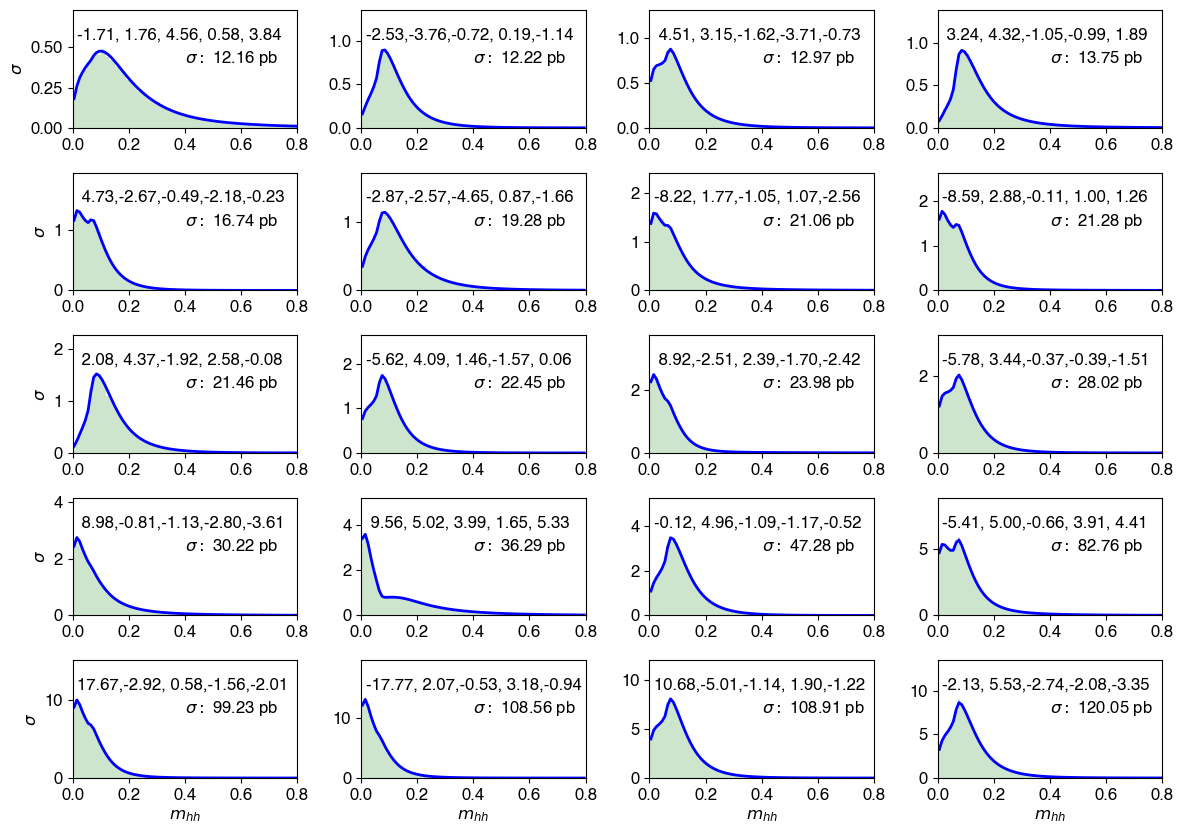

In [50]:
K = 20
J = int(M / K)
for j in range(J):
    i = j + 1
    filename='figures/fig_spectra_comparisons_%3.3d.png' % i
    start = j * K
    end   = start + K
    print(start, end)
    plot_spectra(data[start:end], filename=filename)